## 使用机器学习方法对高光谱进行分类

In [1]:
## 导包
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from  scipy.io import loadmat

## 数据的加载与准备
使用 scipy.io.loadmat() 加载高光谱数据文件

加载高光谱图像数据 (X) 和对应的地面真实标签 (y)

定义类别标签和名称的映射关系

In [ ]:

X = loadmat('./dataset/Indian_pines_corrected.mat')['indian_pines_corrected']

In [4]:
y = loadmat('./dataset/Indian_pines_gt.mat')['indian_pines_gt']

In [5]:
# 定义标签和对应的名字
class_labels = {'1':'Alfalfa',
                '2':'Corn-notill',
                '3':'Corn-mintill',
                '4':'Corn',
                '5':'Grass-pasture',
                '6':'Grass-trees',
                '7':'Grass-pasture-mowed',
                '8':'Hay-windrowed',
                '9':'Oats',
                '10':'Soybean-notill',
                '11':'Soybean-mintill',
                '12':'Soybean-clean',
                '13':'Wheat',
                '14':'Woods',
                '15':'Buildings-Grass-Trees-Drives',
                '16':'Stone-Steel-Towers',
               }

In [6]:
# 各个标签的名字
names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture', 'Grass-trees',
         'Grass-pasture-mowed', 'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
         'Soybean-clean', 'Wheat', 'Woods', 'Buildings Grass Trees Drives', 'Stone Steel Towers']

In [7]:
## 使用SVM进行分类
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
# 这里的操作是将光谱保存到csv文件便于后期剔除背景进行分类
pd.DataFrame(y).to_csv("df_indian_pines_gt.csv", index = False) # 将标签存到表格
# 将三维高光谱数据重塑为二维矩阵形式
q = X.reshape(-1, X.shape[2])
# 将光谱数据与标签合并为一个DataFrame
df = pd.DataFrame(q)
df = pd.concat([df, pd.DataFrame(y.ravel())], axis=1)
# 为每个波段命名
df.columns= [f'band{i}' for i in range(1, 1+X.shape[2])]+['class']
# 保存处理后的数据到CSV文件，方便机器学习模型读取数据
df.to_csv('indian_pines_all.csv', index=False)

In [ ]:
def svm_matrix_plot(X, y):
    """
    使用SVM对数据进行分类，绘制结果，并统计分类精度、召回率和F1分数
    ----
    param X:数据样本集（不含标签），np.array
    param y:数据集标签，np.array
    """
    # 训练集测试集划分，比例8:2
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11, stratify=y)
    # 实例化分类器，核函数：径向基函数（高斯核）
    svm = SVC(C=100, kernel='rbf', cache_size=10*1024)
    # 训练分类器，使用训练数据
    svm.fit(X_train, y_train)
    # 测试集的预测结果
    ypred = svm.predict(X_test)
    # 分类结果的混淆矩阵
    conf_matrix = confusion_matrix(y_test, ypred) # 计算混淆矩阵
    df_cm = pd.DataFrame(conf_matrix, columns=np.unique(names), index = np.unique(names))
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize = (10,8))
    sns.set(font_scale = 1.4)#for label size
    sns.heatmap(df_cm, cmap="Reds", annot=True,annot_kws={"size": 16}, fmt='d')
    
    return svm, y_test, ypred

In [12]:
def plot_classify(svm, q, save_name='IP_cmap'):
    """
    绘制分类结果
    ----
    param svm：训练好的svm分类器
    param q：数据集，DataFrame
    """
    l=[]
    for i in range(q.shape[0]):
        if q.iloc[i, -1] == 0:
            l.append(0)
        else:
            l.append(svm.predict(q.iloc[i, :-1].values.reshape(1, -1))[0])

    clmap = np.array(l).reshape(145, 145).astype('float')
    plt.figure(figsize=(10, 8))
    plt.imshow(clmap, cmap='nipy_spectral')
    plt.colorbar()
    plt.axis('off')
    plt.savefig(f'./results/{save_name}.png')
    plt.show()

In [13]:
# 重新读取数据和标签
df = pd.read_csv('indian_pines_all.csv')

In [16]:
df.head()

,band1,band2,band3,band4,band5,band6,band7,band8,band9,band10,...,band192,band193,band194,band195,band196,band197,band198,band199,band200,class
0,3172,4142,4506,4279,4782,5048,5213,5106,5053,4750,...,1094,1090,1112,1090,1062,1069,1057,1020,1020,3
1,2580,4266,4502,4426,4853,5249,5352,5353,5347,5065,...,1108,1104,1117,1091,1079,1085,1064,1029,1020,3
2,3687,4266,4421,4498,5019,5293,5438,5427,5383,5132,...,1111,1114,1114,1100,1065,1092,1061,1030,1016,3
3,2749,4258,4603,4493,4958,5234,5417,5355,5349,5096,...,1122,1108,1109,1109,1071,1088,1060,1030,1006,3
4,2746,4018,4675,4417,4886,5117,5215,5096,5098,4834,...,1110,1107,1112,1094,1072,1087,1052,1034,1019,3


In [ ]:
# 去除掉背景（0类）
x = df[df['class'] != 0]
X = x.iloc[:, :-1].values
y = x.iloc[:, -1].values

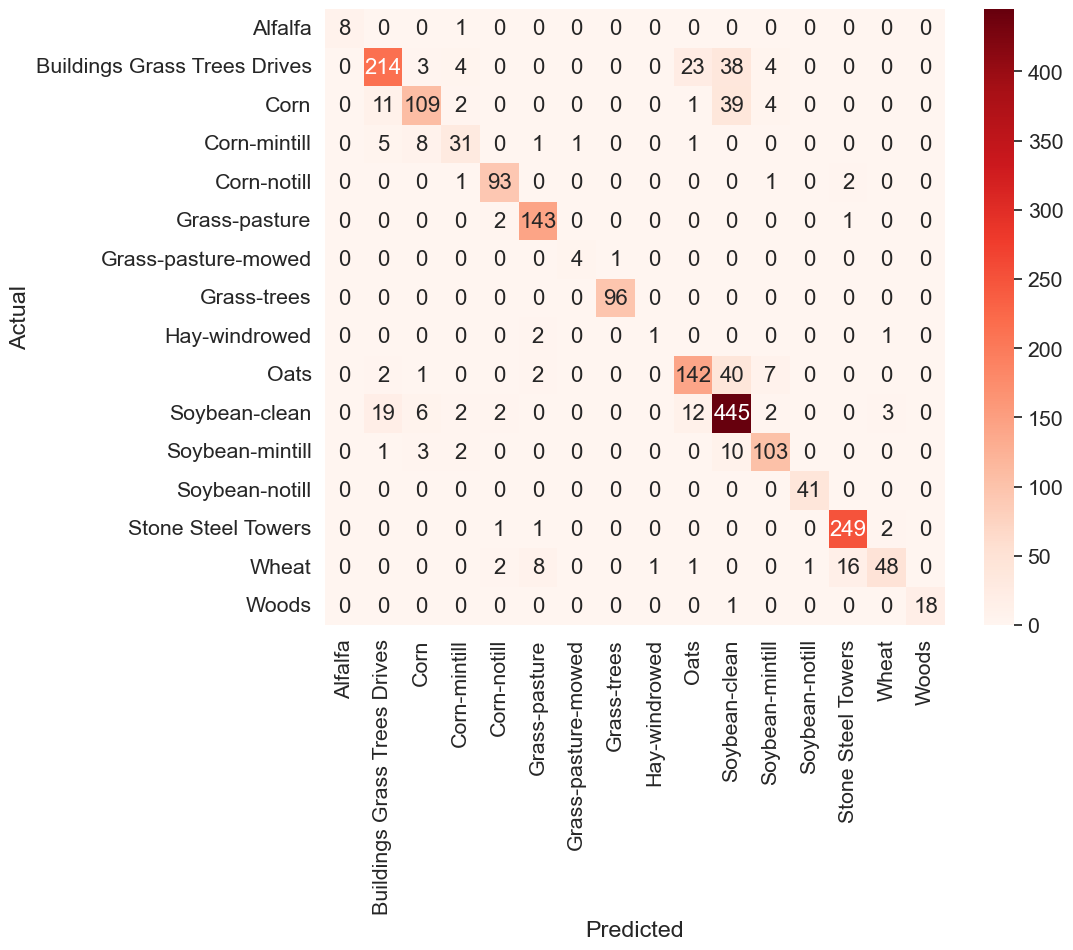

In [ ]:
# 调用SVM预测方法进行预测
svm, y_test, ypred = svm_matrix_plot(X, y)

In [17]:
print(classification_report(y_test, ypred, target_names = names)) # 打印分类结果

                              precision    recall  f1-score   support

                     Alfalfa       1.00      0.89      0.94         9
                 Corn-notill       0.85      0.75      0.80       286
                Corn-mintill       0.84      0.66      0.74       166
                        Corn       0.72      0.66      0.69        47
               Grass-pasture       0.93      0.96      0.94        97
                 Grass-trees       0.91      0.98      0.94       146
         Grass-pasture-mowed       0.80      0.80      0.80         5
               Hay-windrowed       0.99      1.00      0.99        96
                        Oats       0.50      0.25      0.33         4
              Soybean-notill       0.79      0.73      0.76       194
             Soybean-mintill       0.78      0.91      0.84       491
               Soybean-clean       0.85      0.87      0.86       119
                       Wheat       0.98      1.00      0.99        41
                   

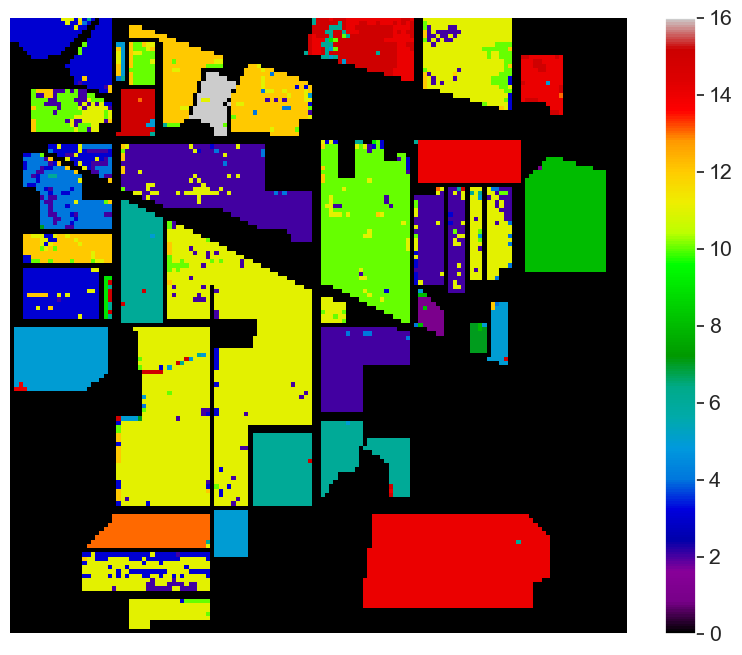

In [18]:
# 可视化分类结果
plot_classify(svm, df, save_name = 'IP_SVM_Orig')

In [ ]:
## 使用PCA降维，然后分类

In [19]:
from sklearn.decomposition import PCA

pca_components = 50
pca = PCA(n_components = pca_components)
data = df.iloc[:, :-1].values
dt = pca.fit_transform(data)

In [20]:
# 将降维之后的光谱和类别进行拼接创建一个新的数据
q = pd.concat([pd.DataFrame(data = dt), pd.DataFrame(df.iloc[:, -1])], axis = 1)
q.columns = [f'PC-{i}' for i in range(1, pca_components+1)]+['class']

In [21]:
q.head()

,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,PC-10,...,PC-42,PC-43,PC-44,PC-45,PC-46,PC-47,PC-48,PC-49,PC-50,class
0,5014.905985,-1456.863260,72.697049,71.204926,-435.686985,-68.840318,-134.809864,304.372455,256.432994,66.630999,...,7.219730,-67.989578,98.721564,25.095257,46.913222,4.976732,23.604549,-29.224580,-69.679783,3
1,5601.383743,2023.450087,350.134661,-528.465053,148.088296,-288.359031,-202.956863,-240.848020,-474.857836,-93.493771,...,-8.325960,-14.802372,48.198445,-56.200235,9.298071,-1.941736,-14.542037,-24.024475,-67.698322,3
2,5796.135442,3090.394852,490.539929,-760.214346,259.933303,-131.611181,-172.927304,-205.911237,572.491978,191.622014,...,6.052947,11.751196,-13.271799,-137.887551,27.103948,36.394854,36.495065,-20.268499,-58.394823,3
3,5586.204575,2369.376085,356.274719,-502.687155,146.554951,-306.679326,-251.071095,-234.966433,-314.023248,-54.962246,...,28.289417,-29.190102,74.136672,-6.903011,44.521142,14.325024,-6.531956,20.396631,-48.922193,3
4,5020.990792,-339.603390,-23.007525,-92.556769,-368.495443,-438.266709,-502.715429,345.536587,-188.352757,67.506061,...,46.756325,-101.560795,139.485647,99.365248,68.453213,19.267719,29.546286,70.415027,-37.565652,3


In [22]:
# 将降维之后的光谱数据进行可视化
def plot_pca(q):
    fig = plt.figure(figsize = (20, 10))
    for i in range(1, 1+8):
        fig.add_subplot(2,4, i)
        plt.imshow(q.loc[:, f'PC-{i}'].values.reshape(145, 145), cmap='nipy_spectral')
        plt.axis('off')
        plt.title(f'Band - {i}')

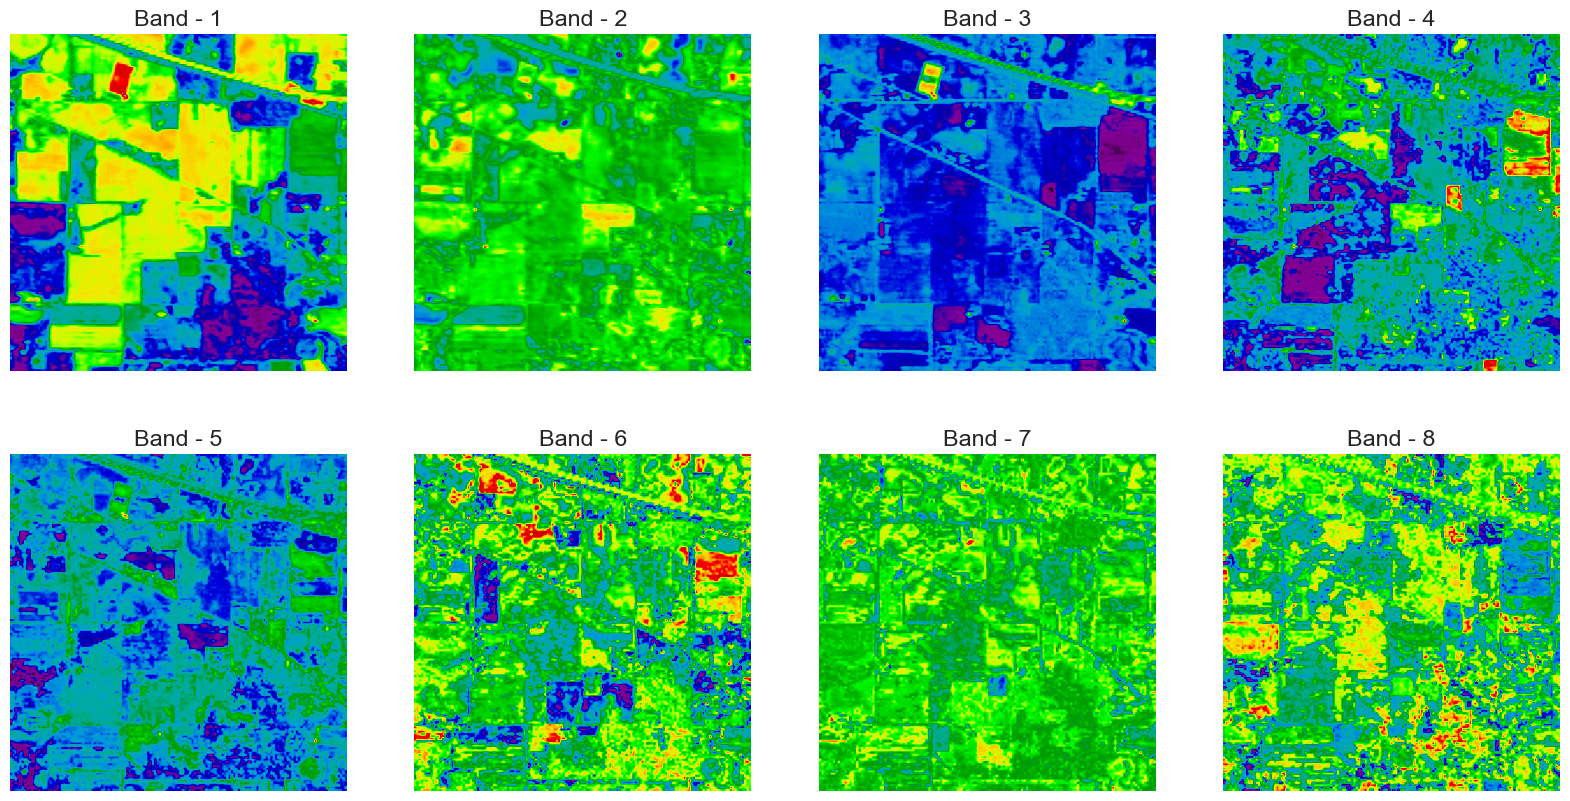

In [23]:
plot_pca(q)

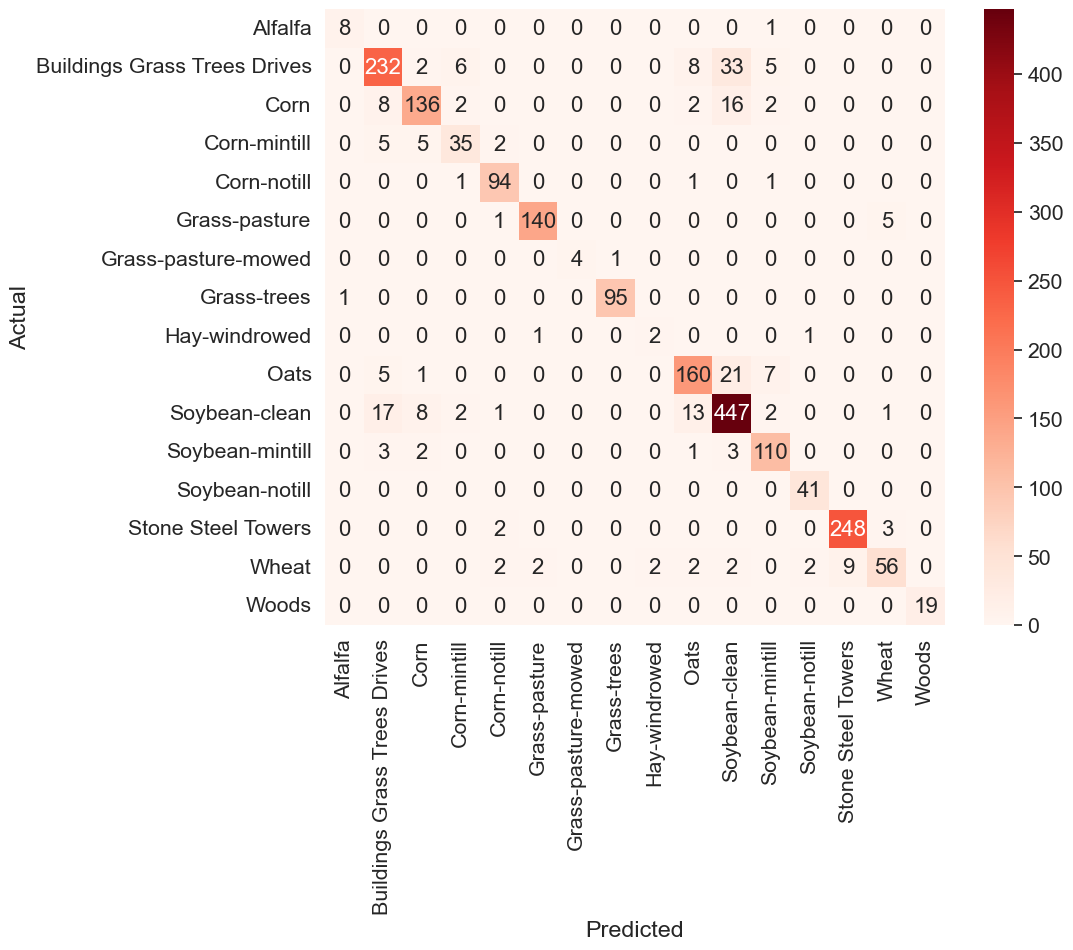

In [24]:
# 使用降维之后的数据重新进行分类
# 去除掉背景（0类）
x = q[q['class'] != 0]
X = x.iloc[:, :-1].values
y = x.loc[:, 'class'].values

svm, y_test, ypred = svm_matrix_plot(X, y)

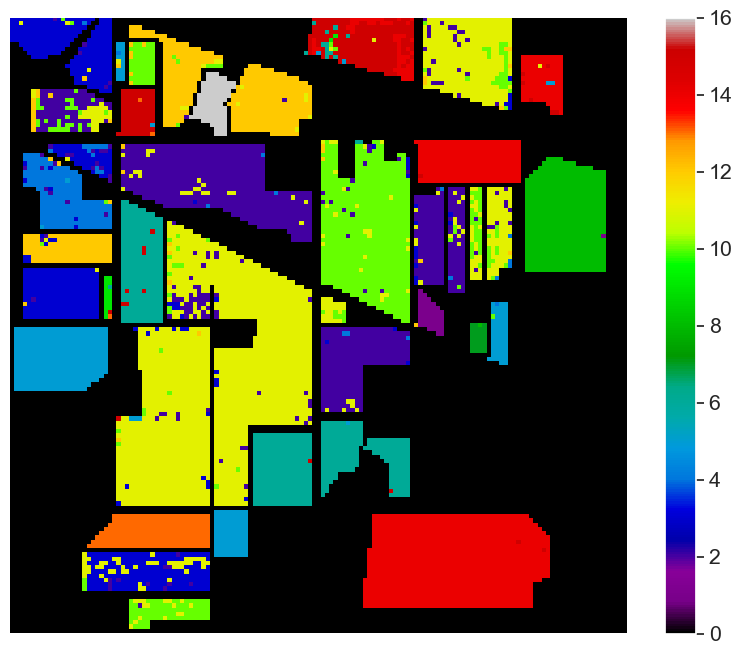

In [25]:
# 绘制降维之后的数据分类结果
plot_classify(svm, q, save_name = 'IP_SVM_PCA')